In [1]:
import sys
sys.path.insert(0, '.')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import get_sun
from astropy.time import Time

from utils.plotting import (
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, EMPHASIS_SIZE,
    LW_FINE, LW_GUIDE, NEUTRAL_COLOR, PRIMARY_COLOR,
    SCATTER_S_FINE,
)


In [2]:
DATA_DIR = Path('../../data/lab03/sun_calibration')

# Default plot frequency window [GHz] — applied to all spectral/waterfall axes
PLOT_BAND_GHZ = (9.9, 10.0)

paths = sorted(DATA_DIR.glob('*.npz'))
files = [np.load(p) for p in paths]
print(f'Loaded {len(files)} captures from {DATA_DIR.resolve()}')

f0       = files[0]
F_S_HZ   = float(f0['f_s_hz'])   if 'f_s_hz'   in f0 else 500e6
F_RF0_HZ = float(f0['f_rf0_hz']) if 'f_rf0_hz' in f0 else 9790e6
N_CH     = int(f0['corr'].shape[0])
N_FFT    = int(f0['n_fft'])       if 'n_fft'    in f0 else 2048
DF_HZ    = F_S_HZ / N_FFT

# Sky-frequency axis for all 1024 channels (SNAP 2048-pt real FFT)
# f_sky(k) = F_RF0 + k * F_S/N_FFT
F_SKY_GHZ = (F_RF0_HZ + np.arange(N_CH) * DF_HZ) / 1e9

# Global peak amplitude (excluding DC ch 0) — used to normalise all spectra
all_amp   = np.array([np.abs(f['corr']) for f in files])  # (N, N_CH)
all_amp[:, 0] = 0.0                                        # zero DC
AMP_PEAK  = all_amp.max()

print(f'Band       : {F_SKY_GHZ[1]:.4f} -- {F_SKY_GHZ[-1]:.4f} GHz  '
      f'({DF_HZ/1e3:.1f} kHz/ch, {N_CH} ch)')
print(f'Global peak: {AMP_PEAK:.4f}  (used for normalisation)')


Loaded 184 captures from /Users/junruiting/GitHub/ay-121/data/lab03/sun_calibration
Band       : 9.7902 -- 10.0398 GHz  (244.1 kHz/ch, 1024 ch)
Global peak: 1.7434  (used for normalisation)


In [3]:
# n     = len(files)
# NCOLS = 4
# nrows = int(np.ceil(n / NCOLS))
#
# fig, axes = plt.subplots(
#     nrows, NCOLS,
#     figsize=(TEXTWIDTH_IN, 2.2 * nrows),
# )
# axes_flat = np.array(axes).flatten()
#
# for i, f in enumerate(files):
#     ax  = axes_flat[i]
#     amp = np.abs(f['corr']).astype(float) / AMP_PEAK   # dimensionless in [0, 1]
#     amp[0] = np.nan                                     # mask DC / LO
#
#     ax.plot(F_SKY_GHZ, amp, lw=LW_FINE, color=PRIMARY_COLOR)
#
#     ax.set_title(
#         rf'\textrm{{cap\,{i:03d}}}' + '\n' +
#         rf'$\mathrm{{Alt}}={float(f["alt_deg"]):.1f}^{{\circ}}$',
#     )
#
#     if i % NCOLS == 0:
#         ax.set_ylabel(r'$|V_{12}| / |V_{12}|_{\rm peak}$')
#     if i >= (nrows - 1) * NCOLS:
#         ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
#         ax.tick_params(axis='x', rotation=30)
#     ax.tick_params(axis='y')
#     ax.set_xlim(*PLOT_BAND_GHZ)
#     ax.set_ylim(0, 1.05)
#
# # Hide unused axes
# for ax in axes_flat[n:]:
#     ax.set_visible(False)
#
# fig.suptitle(
#     rf'Sun --- cross-correlation spectra '
#     rf'({n}\,captures, $\Delta f={DF_HZ/1e3:.1f}$\,kHz)',
# )
# fig.tight_layout()
# plt.show()


In [4]:
# ---------------------------------------------------------------------------
# Compute hour angle for each capture (sorted chronologically)
# The Sun's RA changes ~1°/day, so it must be recomputed per capture.
# ---------------------------------------------------------------------------

NCH_LON_DEG = -122.2573   # NCH site longitude (degrees east)

def _mid_unix(f):
    """Midpoint unix timestamp; falls back to legacy 'unix_time' key."""
    if 'unix_time_start' in f:
        return (float(f['unix_time_start']) + float(f['unix_time_end'])) / 2
    return float(f['unix_time'])

def _lst_deg(unix_t):
    jd = unix_t / 86400.0 + 2440587.5
    T  = (jd - 2451545.0) / 36525.0
    g  = (280.46061837 + 360.98564736629 * (jd - 2451545.0)
          + T**2 * 0.000387933 - T**3 / 38710000.0)
    return (g + NCH_LON_DEG) % 360.0

def _sun_ra_deg(unix_t):
    """Sun's J2000 RA in degrees at the given unix time."""
    t = Time(unix_t, format='unix')
    sun = get_sun(t)
    return sun.ra.deg

# Sort files by mid-capture unix time
unix_mid  = np.array([_mid_unix(f) for f in files])
order     = np.argsort(unix_mid)
unix_sort = unix_mid[order]
files_s   = [files[j]  for j in order]
paths_s   = [paths[j]  for j in order]
t_rel     = unix_sort - unix_sort[0]          # seconds since first capture

# Per-capture Sun RA and HA
# Sun moves ~1°/day → must recompute RA at each capture's midpoint
lst_arr    = np.array([_lst_deg(t) for t in unix_sort])
sun_ra_arr = np.array([_sun_ra_deg(t) for t in unix_sort])
ha_deg     = (lst_arr - sun_ra_arr) % 360.0
ha_deg[ha_deg > 180.0] -= 360.0

# Peak channel across all captures (excluding DC)
k_peak     = int(np.argmax(all_amp.mean(axis=0)))
F_PEAK_GHZ = F_SKY_GHZ[k_peak]

vis_peak   = np.array([f['corr'][k_peak] for f in files_s])
amp_peak   = np.abs(vis_peak) / AMP_PEAK
phase_peak = np.rad2deg(np.angle(vis_peak))

print(f'Sun RA range : {sun_ra_arr.min():.4f}° – {sun_ra_arr.max():.4f}°  '
      f'(span {sun_ra_arr.max()-sun_ra_arr.min():.4f}°)')
print(f'HA range     : {ha_deg.min():.2f}° → {ha_deg.max():.2f}°  '
      f'({ha_deg.max() - ha_deg.min():.2f}° span)')
print(f'Peak channel : k={k_peak},  f_sky={F_PEAK_GHZ:.4f} GHz')
print(f'Amp  (norm)  : mean={amp_peak.mean():.3f},  std={amp_peak.std():.3f}')
print(f'Phase        : mean={phase_peak.mean():.1f}°,  std={phase_peak.std():.1f}°')


Sun RA range : 356.9760° – 357.0141°  (span 0.0381°)
HA range     : -61.87° → -46.88°  (14.99° span)
Peak channel : k=622,  f_sky=9.9419 GHz
Amp  (norm)  : mean=0.631,  std=0.057
Phase        : mean=0.1°,  std=175.7°


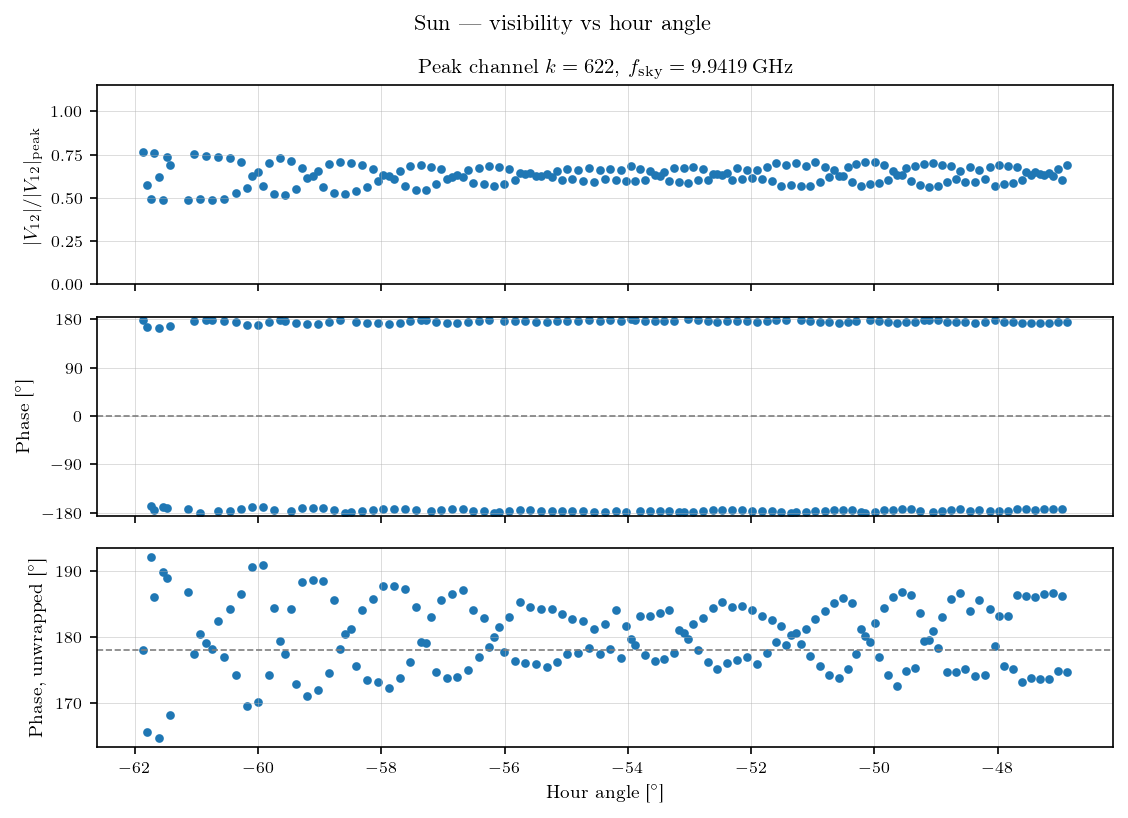

In [5]:
# ---------------------------------------------------------------------------
# Amplitude vs HA  +  wrapped phase vs HA  +  unwrapped phase vs HA
# ---------------------------------------------------------------------------

phase_unwrapped = np.rad2deg(np.unwrap(np.deg2rad(phase_peak)))

fig, axes = plt.subplots(3, 1, figsize=(TEXTWIDTH_IN, 5.5), sharex=True)

# --- Amplitude ---
axes[0].scatter(ha_deg, amp_peak, s=SCATTER_S_FINE, color=PRIMARY_COLOR)
axes[0].set_ylabel(r'$|V_{12}| / |V_{12}|_{\rm peak}$')
axes[0].set_title(
    rf'Peak channel $k={k_peak}$,\ $f_{{\rm sky}}={F_PEAK_GHZ:.4f}$\,GHz'
)
axes[0].set_ylim(0, 1.15)

# --- Wrapped phase ---
axes[1].scatter(ha_deg, phase_peak, s=SCATTER_S_FINE, color=PRIMARY_COLOR)
axes[1].axhline(0, color=NEUTRAL_COLOR, lw=LW_GUIDE, ls='--')
axes[1].set_ylabel(r'Phase [$^\circ$]')
axes[1].set_ylim(-185, 185)
axes[1].set_yticks([-180, -90, 0, 90, 180])

# --- Unwrapped phase ---
axes[2].scatter(ha_deg, phase_unwrapped, s=SCATTER_S_FINE, color=PRIMARY_COLOR)
axes[2].axhline(phase_unwrapped[0], color=NEUTRAL_COLOR, lw=LW_GUIDE, ls='--')
axes[2].set_ylabel(r'Phase, unwrapped [$^\circ$]')
axes[2].set_xlabel(r'Hour angle [$^\circ$]')

fig.suptitle(r'Sun --- visibility vs hour angle')
fig.tight_layout()
plt.show()


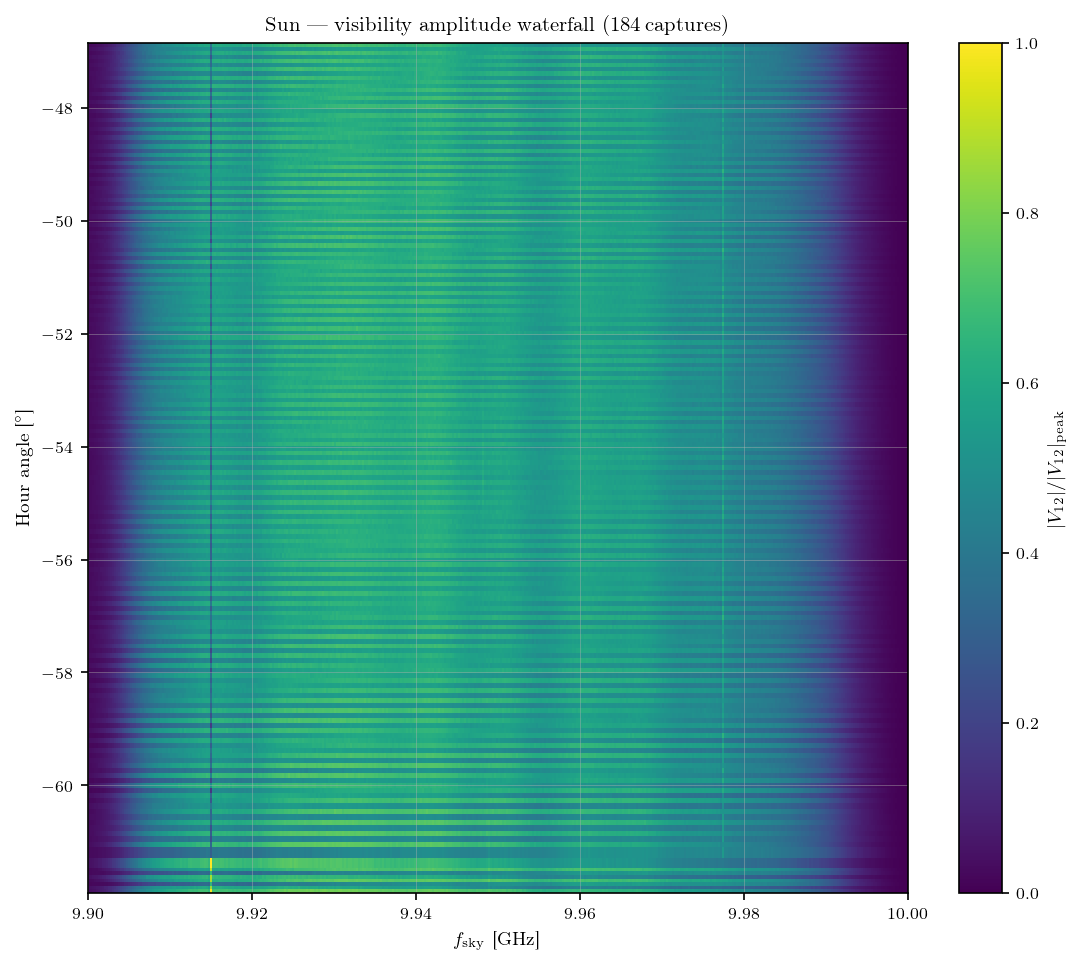

In [6]:
# ---------------------------------------------------------------------------
# Waterfall (spectrogram): amplitude vs frequency × hour angle
# Rows = captures sorted by time; columns = sky-frequency channels
# ---------------------------------------------------------------------------

amp_matrix = np.array([np.abs(f['corr']) / AMP_PEAK for f in files_s])
amp_matrix[:, 0] = np.nan   # mask DC / LO leak

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 6.5))
im = ax.pcolormesh(
    F_SKY_GHZ,
    ha_deg,
    amp_matrix,
    vmin=0, vmax=1,
    cmap='viridis',
    shading='auto',
)
ax.set_xlim(*PLOT_BAND_GHZ)
ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
ax.set_ylabel(r'Hour angle [$^\circ$]')
ax.set_title(
    rf'Sun --- visibility amplitude waterfall '
    rf'({len(files_s)}\,captures)'
)
fig.colorbar(im, ax=ax, label=r'$|V_{12}| / |V_{12}|_{\rm peak}$')
fig.tight_layout()
plt.show()
